In [1]:
import os
import sys
import json
import pickle
import copy
import numpy as np
import optuna
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F

In [3]:
#imbalanced-learn for SMOTE oversampling on XGBoost features
# Install if needed: pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✓ SMOTE available")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠ SMOTE not available — install imbalanced-learn for minority class oversampling")


✓ SMOTE available


In [4]:
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, cohen_kappa_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [5]:
class Config:
    def __init__(self):
        #dataset pathways
        self.data_dir = Path('aptos2019-blindness-detection')
        self.train_csv = self.data_dir/'train.csv'
        self.test_csv = self.data_dir/'IDRID TESTING/B. Disease Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv'
        self.train_images_dir = self.data_dir/'train_images_512'
        self.test_images_dir = self.data_dir/'IDRID TESTING/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set'

        #Model path
        self.model_dir = Path('savemodels')
        self.model_features = Path('extracted_features')
        self.model_results = Path('results')

        #Create Directories 
        for dir_path in [self.model_dir, self.model_features, self.model_results]:
            dir_path.mkdir(parents=True, exist_ok=True)

        self.results_dir = Path('results')
        self.results_dir.mkdir(parents=True, exist_ok=True)

        # Hyperparameters
        self.batch_size = 64
        self.num_classes = 5 #(0-4 severity)
        self.n_splits = 5
        self.random_seed = 42
        self.tuning_img_size = (224, 224) # Fast comparison during Optuna trials
        self.img_size = (512, 512) # for highlightling retina images

        #Phase 1: short tuning run used by Optuna
        self.tuning_epochs = 3
        self.tuning_trails = 15
        #Phase2: Full training with best params
        self.num_epochs = 50
        self.learning_rate = 5e-5

        # Unfreezing strategy
        self.unfreeze_blocks = {
            'resnet50': ['layer4', 'fc'],
            'inception_v3': ['Mixed_7c', 'Mixed_7b', 'Mixed_7a', 'fc'],
            'densenet121': ['denseblock4', 'classifier']
        }

        # Models
        self.pretrained_models = {
            'resnet50': models.resnet50,
            'densenet121': models.densenet121,
            'inceptionV3': models.inception_v3
        }

        # XGBoost parameters
        self.xgb_params = {
            'objective': 'multi:softmax',
            'num_class': 5,
            'max_depth': 6,
            'learning_rate': 0.1,
            'n_estimators': 100,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'n_jobs': -1
        }

        self.xgb_tuning_trails = 30 #Oputna trails for XGBoost

        #Default FC head params
        self.default_head_params = {
            'fc_dim': 512,
            'dropout':0.5,
            'fc_layers': 2
        }

        self.best_head_params = {}
        self.best_xgb_params = None

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def to_dict(self):
        return {k:v for k,v in self.__dict__.items() if not k.startswith('_')}

In [6]:
class DataAugmentation:
    "performing Data augmentation for our images"
    #Minority classes that need extra augmentation
    MINORITY_CLASSES = {1,3,4}

    #How many extra augmented copies to generate per minority sameple
    # e.g factor=3 means each class 1/3/4 image appears ~3x per epoch
    MINORITY_AUGMENT_FACTOR = 3
    @staticmethod
    def get_train_transform(img_size=(512, 512)):

        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=45),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
            transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
            #Randomly apply Gaussian blur to simulate image quality
            #variation across different fundus camera models
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)],
                                   p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    #Stronger augmentation pipeline used only for minority classes
    #   Extra transforms simulate more variation since we have fewer real
    #   examples to learn from for these classes.

    @staticmethod
    def get_minority_train_transform():
        return transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            # Wider rotation range than standard — retinal images are
            # rotationally symmetric so this is medically valid
            transforms.RandomRotation(degrees=45),
            # Stronger color jitter — simulates different camera/lighting
            # conditions that occur across different clinical settings
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.3, hue=0.15),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15),
                                    scale=(0.85, 1.15), shear=10),
            # ── NEW: Randomly apply sharpening to simulate focus variation
            transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
            # ── NEW: Randomly apply Gaussian blur to simulate image quality
            #   variation across different fundus camera models
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)],
                                   p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    
    @staticmethod
    def get_val_transform(img_size=(512, 512)):
        return transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    @staticmethod
    def preprocess_image(image_path):
        transfrom = transforms.Compose([
            transforms.Resize((512,512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        image = Image.open(image_path).convert('RGB')
        return transfrom(image).unsqueeze(0)

In [7]:
class CustomAptos(Dataset):
    #Customizing the AptosDataset for our use
    def __init__(self, dataframe, image_dir, transform = None,
                 is_test = False, apply_minority_augment = False):

        self.dataframe = dataframe
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.is_test = is_test

        self.apply_minority_augment =  apply_minority_augment
        self.minority_transform = DataAugmentation.get_minority_train_transform()

        #Each entry is (dataframe_row_idx, use_minority_transform)
        self.sample = []

        for idx in range(len(self.dataframe)):
            label = int(self.dataframe.iloc[idx]['diagnosis']) if not is_test else -1

            #Adding the standard copy for every sample
            self.sample.append((idx, False))

            #Adding the extra augmentated copies for minority classes only
            if apply_minority_augment and label in DataAugmentation.MINORITY_CLASSES:
                for _ in range(DataAugmentation.MINORITY_AUGMENT_FACTOR - 1):
                    self.sample.append((idx, True))

    def __len__(self):
        return len(self.sample)
    
    def __getitem__(self, idx):
        #Upacking the row_idx, use_minority_transform tuple
        row_idx, use_minority = self.sample[idx]

        img_name = self.dataframe.iloc[row_idx]['id_code']
    
        # Handle different image extensions
        image_paths = [
            self.image_dir / f"{img_name}.png",
            self.image_dir / f"{img_name}.jpg",
            self.image_dir / f"{img_name}.jpeg"
        ]

        image_path = next((p for p in image_paths if p.exists()), None)
        if image_path is None:
            raise FileNotFoundError(f"Image not found for {img_name}")
    
        image = Image.open(image_path).convert('RGB')

        #Choosing which transform to apply based on sample type
        if use_minority:
            image = self.minority_transform(image)

        elif self.transform:
            image = self.transform(image)
        
        if self.is_test:
            return image, img_name
            
        label = self.dataframe.iloc[row_idx]['diagnosis']
        return image, label

In [8]:
# ── FocalLoss: Addresses severe class imbalance in the APTOS dataset ────────
#
# Problem: Standard CrossEntropyLoss is dominated by the frequent classes
# (class 0: No DR, class 2: Moderate) causing near-zero recall on rare
# classes (class 1: Mild, class 3: Severe, class 4: Proliferative DR).
#
# Formula: FocalLoss = -alpha_t * (1 - p_t)^gamma * log(p_t)
#
# Two mechanisms work together:
#   1. alpha_t  — per-class weight (inverse frequency). Rare classes get
#                 a higher base weight, same as weighted CrossEntropy.
#
#   2. (1-p_t)^gamma — the "focus" term. When the model is already
#                 confident and correct (p_t → 1), this term → 0,
#                 silencing easy examples. When the model is uncertain
#                 or wrong (p_t → 0), this term → 1, preserving the
#                 full loss signal and forcing attention on hard samples.
#
# Example: A class 0 sample predicted with 92% confidence contributes
#   CrossEntropy loss = 0.083, but Focal loss = 0.00066 (nearly silent).
#   A class 1 sample predicted with only 18% confidence contributes
#   CrossEntropy loss = 1.715, Focal loss = 1.155 (still dominant).
#   This means gradient updates are driven almost entirely by the hard
#   minority classes rather than the easy majority.
#
# gamma=2: Standard value from the original RetinaNet paper (Lin et al.,
#   2017). gamma=0 reduces to plain weighted CrossEntropy. Higher gamma
#   increases focus but can destabilize training.
#
# Expected impact: Improved recall for DR grades 1, 3, and 4, at the
#   cost of a minor drop in grade 0 accuracy — a clinically acceptable
#   tradeoff since missing severe DR is far more dangerous than a false
#   positive.
# ────────────────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha = None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, tragets):
        ce_loss = F.cross_entropy(inputs, tragets, weight=self.alpha, reduction='none')

        pt = torch.exp(-ce_loss)
        focal_loss = (1-pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        
        return focal_loss

In [9]:
class DRModelManager:
    #Manages multiple pre-trained models for diabetic retinopathy

    def __init__(self, config, model_name, tuning_params):
        self.config = config
        self.model_name = model_name
        self.device = config.device
        #Support for dynamic hyperparameters(Optuna)
        #Default Params to use if tuning_params is None.
        self.params = tuning_params if tuning_params else config.default_head_params
        self.model = None
        self.feature_extractor = None
        self._initialize_model_finetune()

    # Helper method to build variable-size classification heads
    def _build_dynamic_head(self, in_features):
        layers = []

        #layer1: Dropout -> Linear -> BN -> Activation
        layers.append(nn.Dropout(self.params['dropout']))
        layers.append(nn.Linear(in_features, self.params['fc_dim']))
        layers.append(nn.BatchNorm1d(self.params['fc_dim']))
        layers.append(nn.LeakyReLU(inplace=True))

        #Optional Layer 2 (depth controlled by Optuna/Controlled by tuning_params)
        if self.params.get('fc_layers', 2) == 2:
            layers.append(nn.Dropout(self.params['dropout'] * 0.5))
            layers.append(nn.Linear(self.params['fc_dim'], self.params['fc_dim'] // 2))
            layers.append(nn.BatchNorm1d(self.params['fc_dim'] // 2))
            layers.append(nn.LeakyReLU(inplace=True))
            last_dim = self.params['fc_dim'] // 2

        else:
            last_dim = self.params['fc_dim']

        #Final Classification Layer
        layers.append(nn.Dropout(0.2))
        layers.append(nn.Linear(last_dim, self.config.num_classes))

        return nn.Sequential(*layers)
    
    def _initialize_model_finetune(self):
        """Initialize pre-trained model with fine-tuning on last blocks only"""
        
        if self.model_name == 'resnet50':
            self._initialize_resnet50_finetune()
            
        elif self.model_name == 'inceptionV3':
            self._initialize_inception_v3_finetune()
            
        elif self.model_name == 'densenet121':
            self._initialize_densenet121_finetune()
        
        else:
            raise ValueError(f"Model {self.model_name} not supported")
        
        self.model.to(self.device)
        
        # Create feature extractor (all layers except the final classifier)
        self._feature_extractor()
    
    def _initialize_resnet50_finetune(self):
        """Fine-tune ResNet50: Freeze all, unfreeze layer4 and FC"""
        self.model = models.resnet50(pretrained = True)

        # CONCEPT: Freezing the Backbone
        # We start by turning off gradient calculation for ALL layers.
        # This locks the weights of the feature extractor (layers 1-3)
        # so they act as a static "retinal feature detector"
        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Also unfreeze the BatchNorm layers in the last block
        for module in self.model.layer4.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.train()  # Set to training mode
                for param in module.parameters():
                    param.requires_grad = True

        # Using dynamic head builder instead of hardcoded Sequential
        num_feature = self.model.fc.in_features
        self.model.fc = self._build_dynamic_head(num_feature)
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def _initialize_inception_v3_finetune(self):
        """Fine-tune InceptionV3: Unfreeze Mixed_7 blocks"""
        # Note: aux_logits=True is required for stable Inception training
        self.model = models.inception_v3(pretrained=True, aux_logits=True)

        for param in self.model.parameters():
            param.requires_grad = False
        # InceptionV3 architecture: Unfreeze from Mixed_7c onward (last few blocks)
        # Mixed_6a to Mixed_7c are the later blocks

        for name, param in self.model.named_parameters():
            if 'Mixed_7' in name or 'Mixed_6e' in name or 'Mixed_6d' in name: # type: ignore
                param.requires_grad = True
            if 'bn' in name or 'BatchNorm' in name:  # Unfreeze BatchNorm in unfrozen blocks
                if 'Mixed_7' in name or 'Mixed_6' in name:
                    param.requires_grad = True

        #Handle the Auxiliary Classifier such that it does not return 1000 classe 
        #intsead it return our 5 class output
        if self.model.AuxLogits is not None:
            num_aux_ftrs = self.model.AuxLogits.fc.in_features
            self.model.AuxLogits.fc = nn.Linear(num_aux_ftrs, self.config.num_classes)
            for param in self.model.AuxLogits.fc.parameters():
                param.requires_grad = True
                
        # Replace the final FC layer
        num_features = self.model.fc.in_features
        self.model.fc = self._build_dynamic_head(num_features)
        
        # Set FC layer to trainable
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def _initialize_densenet121_finetune(self):
        """Fine-tune DenseNet121: only train last dense block"""
        self.model = models.densenet121(pretrained=True)
        
        # FREEZE ALL LAYERS FIRST
        for param in self.model.parameters():
            param.requires_grad = False
        
        # DenseNet121: Unfreeze only the last dense block (denseblock4)
        # and transition layer before it
        for name, param in self.model.named_parameters():
            if 'denseblock4' in name or 'norm5' in name:
                param.requires_grad = True
            if 'transition3' in name:  # The transition before last block
                param.requires_grad = True
        
        # Unfreeze BatchNorm layers in the unfrozen blocks
        for name, module in self.model.named_modules():
            if isinstance(module, nn.BatchNorm2d):
                if 'denseblock4' in name or 'norm5' in name:
                    module.train()
                    for param in module.parameters():
                        param.requires_grad = True
        
        # Get the original classifier's input features
        num_features = self.model.classifier.in_features
        
        # **FIX: Create a new Sequential classifier and replace the old one**
        # DenseNet's classifier is a single Linear layer, so we need to wrap our
        # custom layers in a Sequential and assign to classifier
        
        # First, let's check what type of classifier we have
        print(f"DenseNet classifier type: {type(self.model.classifier)}")
        print(f"DenseNet classifier: {self.model.classifier}")
        
        # **CRITICAL: Replace the classifier with our Sequential**
        self.model.classifier = self._build_dynamic_head(num_features)
        
        # Set classifier to trainable
        for param in self.model.classifier.parameters():
            param.requires_grad = True
        
        print(f"Created new classifier with {num_features} input features")
        print(f"New classifier architecture: {self.model.classifier}")

    def _feature_extractor(self):
        """Creates a version of the model that outputs embeddings"""
        
        # First, verify the model exists
        if self.model is None:
            raise ValueError(f"Model is None! Check initialization for {self.model_name}")
        
        if self.model_name == 'resnet50':
            # Original ResNet50 structure:
            # [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc]

            # We take everything EXCEPT the final FC layer:
            self.feature_extractor = nn.Sequential(*list(self.model.children())[:-1])
            # This gives us: [conv1 → layer4 → avgpool]
            # Output shape: (batch_size, 2048, 1, 1) after avgpool
        
        # InceptionV3 has different structure
        # We need to add AdaptiveAvgPool2d because Inception's pooling might vary
        elif self.model_name == 'inceptionV3':
            # --- FIX FOR INCEPTION V3 ---
            # We cannot simple use nn.Sequential because Inception has a complex graph.
            # Instead, we copy the model and replace the final classification layer (fc)
            # with an Identity layer. This preserves the internal graph while outputting features.
            
            # 1. Create a shallow copy of the model structure to avoid breaking the original
            self.feature_extractor = copy.deepcopy(self.model)
            
            # 2. Disable AuxLogits to prevent tuple outputs ((logits, aux)) during inference
            self.feature_extractor.aux_logits = False
            
            # 3. Replace the final FC layer with Identity
            # This makes the model output the 2048-dim feature vector directly
            self.feature_extractor.fc = nn.Identity()

        # DenseNet structure is different: features + classifier
        elif self.model_name == 'densenet121':
            # FIX: Ensure model has features attribute
            if not hasattr(self.model, 'features'):
                raise AttributeError(f"DenseNet121 model doesn't have 'features' attribute")
            
            self.feature_extractor = nn.Sequential(
                self.model.features,
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((1,1))
            )
            # Output shape: (batch_size, 1024, 1, 1)

        else:
            raise ValueError(f"Unsupported model for feature extraction: {self.model_name}")

        #Before Extraction of(CNN Output):
        #For a batch of 16 images: Shape: (16, 2048, 7, 7)
        # 2048 channels, 7x7 spatial grid

        #After AdaptiveAvgPool2d((1,1)):
        #Shape: (16, 2048, 1, 1)  # Each channel averaged to single value

        #Shape: (16, 2048, 1, 1)  # Each channel averaged to single value
        #Shape: (16, 2048)  # 2048-dimensional feature vector per image

        self.feature_extractor.to(self.device)
        # Set to evaluation mode for inference
        self.feature_extractor.eval()

    def print_trainable_parameters(self):
        """Print which layers are trainable - useful for debugging"""
        print(f"\n{'='*60}")
        print(f"Trainable parameters for {self.model_name}:")
        print('='*60)

        total_parameter = 0
        trainable_parameter = 0 

        for name, param in self.model.named_parameters():
            total_parameter += param.numel()
            if param.requires_grad:
                trainable_parameter += param.numel()
                print(f"✓ TRAINABLE: {name}")
            else:
                print(f"  Frozen: {name}")
        
        print(f"\nTotal parameters: {total_parameter:,}")
        print(f"Trainable parameters: {trainable_parameter:,}")
        print(f"Percentage trainable: {100 * trainable_parameter / total_parameter:.2f}%")
        print('='*60)
        
        return trainable_parameter, total_parameter
    
    def get_model(self):
        return self.model
    
    def get_feature_extractor(self):
        if self.feature_extractor is None:
            raise ValueError("Feature extractor not initialized. Call _feature_extractor() first.")
        return self.feature_extractor
    
    def save_model(self, path):
        """Save the important parameters and model details to use even after the training is done"""
        
        if self.model is None:
            raise ValueError("Cannot save: model is not initialized")
            
        if self.feature_extractor is None:
            raise ValueError("Cannot save: feature extractor is not initialized")

        trainable_names = [name for name, p in self.model.named_parameters() if p.requires_grad]

        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_name': self.model_name,
            'config': self.config.to_dict(),
            'trainable_layers': trainable_names,
            'feature_extractor_state_dict': self.feature_extractor.state_dict()
        }, path)
        
        print(f"Model saved to {path}")
                
    def load_model(self, path):
        """Loading the saved model"""
        
        # First, ensure the model architecture is initialized
        if self.model is None:
            self._initialize_model_finetune()
            
        # FIX: Add weights_only=False to allow loading Config objects
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        
        # Load model state dictionary
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        # Verify model name matches
        if 'model_name' in checkpoint and checkpoint['model_name'] != self.model_name:
            print(f"Warning: Loading {checkpoint['model_name']} into {self.model_name}")

        # Loading the trainable parameter if in the model
        if 'trainable_layers' in checkpoint:
            # First freeze all
            for param in self.model.parameters():
                param.requires_grad = False
            # Then unfreeze saved trainable layers
            for name, param in self.model.named_parameters():
                if name in checkpoint['trainable_layers']:
                    param.requires_grad = True
        
        self._feature_extractor()
        
        print(f"Model loaded from {path}")
        return self.model
    
    def debug_model_state(self):
        """Debug method to check model initialization"""
        print(f"\n{'='*60}")
        print(f"Debug: {self.model_name}")
        print(f"{'='*60}")
        print(f"1. Model is None: {self.model is None}")
        print(f"2. Feature extractor is None: {self.feature_extractor is None}")
        
        if self.model is not None:
            print(f"3. Model type: {type(self.model)}")
            print(f"4. Model has children: {hasattr(self.model, 'children')}")
            
            if hasattr(self.model, 'children'):
                children = list(self.model.children())
                print(f"5. Number of children: {len(children)}")
                print(f"6. First 3 children types:")
                for i, child in enumerate(children[:3]):
                    print(f"   [{i}] {type(child).__name__}")
                if len(children) > 3:
                    print(f"   ... and {len(children)-3} more")
        
        print(f"{'='*60}")

        

In [10]:
class DRTrainer:
    "Training engine for our fine tune CNNs"

    def __init__(self, config, model_manager,train_loader, trial=None):
        self.config = config
        self.model_manager = model_manager
        self.model = self.model_manager.get_model()
        self.device = self.config.device
        self.trial = trial
        self.tuning_mode = trial is not None
        
        #Printing the Trainable parameter information
        if not self.tuning_mode:
            self.model_manager.print_trainable_parameters()

        training_params = [p for p in self.model.parameters() if p.requires_grad]

        if len(training_params) == 0:
            raise ValueError("No training parameters found. Check the fine tuning.")
        
        print(f"[{model_manager.model_name}] {len(training_params)} trainable parameter tensors")
        
        # Different learning rates for fine-tuned layers vs new layers
        # Higher LR for new layers, lower LR for fine-tuned pretrained layers
        
        # Group parameters by type
        new_layers = []
        finetune_layers = []
        
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                if 'fc' in name or 'classifier' in name:
                    new_layers.append(param)  # New classifier layers
                else:
                    finetune_layers.append(param)  # Fine-tuned pretrained layers
        #Allowing Optuna to tune the learning rate
        base_lr = config.learning_rate
        if trial is not None:
            base_lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

        # Create parameter groups with different learning rates
        # We pass these groups to the optimizer
        param_groups = [
            {'params': finetune_layers, 'lr': base_lr * 0.1},
            {'params': new_layers, 'lr': base_lr}  
        ]
        self.optimizer = optim.AdamW(param_groups, lr=base_lr, weight_decay=1e-4)

        #Tuning_maode for to select num of epochs for tuning and training phase
        self.tuning_mode = trial is not None
        run_epochs = config.tuning_epochs if self.tuning_mode else config.num_epochs

        #lr scheduler for countinuouly chaning learning and then restarting with higher after some epochs
        # Scheduler: OneCycleLR is a smart learning rate scheduler that follows a specific policy:
        # Warm up: Gradually increase learning rate from low to high
        #Annealing: Gradually decrease learning rate from high to low
        #Single cycle: All done in one complete cycle (hence the name)

        steps = max(1,len(train_loader))
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer, 
            max_lr=[base_lr * 0.1, base_lr],
            epochs= run_epochs,
            steps_per_epoch=steps, # Approx batches (3662 / 32)
            pct_start=0.1 if self.tuning_mode else 0.3
        )

        # Loss fucntion with class wieght imbalance
        self.criterion = self._get_focal_loss()

        #initialize GradScaler for mixed precision training if CUDA is available
        self.scaler = torch.GradScaler('cuda') if torch.cuda.is_available() else None

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': [],
            'learning_rates': []
        }

    def _get_focal_loss(self, gamma=2.0):
        """Compute balanced class weights then plug into FocalLoss.
        Falls back to plain FocalLoss (no weights) if CSV not found."""
        if not self.config.train_csv.exists():
            print("Warning: train CSV not found - using unweighted Focal Loss")
            return FocalLoss(gamma=gamma)
        
        df = pd.read_csv(self.config.train_csv)
        counts = df['diagnosis'].value_counts().sort_index().values.astype(float)
        total = counts.sum()
        weights = total / (len(counts) * counts)
        weights = weights / weights.sum()
        class_weights = torch.tensor(weights, dtype=torch.float32).to(self.device)
        print(f"[{self.model_manager.model_name}] Class weights: {class_weights.cpu().numpy().round(3)}")
        return FocalLoss(alpha=class_weights, gamma=gamma)
    
    def train_epoch(self, train_loader, epoch, total_epochs):
        self.model.train()

        #Handling the BatchNorm blocks in fine tunning to make sure they are in traning mode
        for _, module in self.model.named_modules():
            if isinstance(module, nn.BatchNorm2d) and hasattr(module, 'weight'):
                if module.weight.requires_grad:
                    module.train()

        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{total_epochs}', leave=False)

        for batch_idx, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()

            #Handling the InceptionV3 duo outputs during training (output, aux_output)
            # Adding autocast context for mixed precision compatibility
            with torch.autocast('cuda', enabled=(self.scaler is not None)):
                if self.model_manager.model_name == 'inceptionV3':
                    outputs, aux_outputs = self.model(inputs)
                    # outputs: Main prediction from final layer
                    # aux_outputs: Auxiliary prediction from middle layer

                    loss = self.criterion(outputs, labels) + \
                           0.4 * self.criterion(aux_outputs, labels)
                else:
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

            # CONCEPT: Gradient Clipping
            # Fine-tuning can sometimes produce large gradients that destabilize the
            # pre-trained weights. We clip the gradient norm to 1.0 to ensure smooth updates.
            #for faster training we use mix precision training where we use FP16 and Fp32
            if self.scaler:  # If we have a GPU that supports mixed precision
                # 1. Scale up the loss (prevents underflow)
                self.scaler.scale(loss).backward()
                # Loss is multiplied by e.g., 65536 before backward pass
                
                # 2. Unscale gradients before optimizer step
                self.scaler.unscale_(self.optimizer)
                # Now gradients are back to normal scale
                
                # 3. Clip gradients (prevent overflow)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in self.model.parameters() if p.requires_grad], 
                    max_norm=1.0
                )
                
                # 4. Optimizer step with scaling
                self.scaler.step(self.optimizer)
                
                # 5. Update scale factor for next iteration
                self.scaler.update()
                # OneCycleLR requires per-batch stepping
                self.scheduler.step()

            else:
                loss.backward()

                #gradient Clipping 
                torch.nn.utils.clip_grad_norm_(
                    [p for p in self.model.parameters() if p.requires_grad], 
                    max_norm=1.0)

                self.optimizer.step()

            #statistics
            #running_loss: Sum of all batch losses in the current epoch
            #Example: If 100 batches with losses [0.5, 0.4, 0.3, ...], running_loss = 0.5 + 0.4 + 0.3 + ...
            running_loss += loss.item()

            #getting the prediction outputs where we recive 5 output and only choose max value from each iteration
            _, predicted = outputs.max(1)
            total += labels.size(0)

            #Gettting the total correctly predicted labels in each iteration
            correct += predicted.eq(labels).sum().item()

            #showing the progress bar to monitor the performance
            pbar.set_postfix({
                'loss': running_loss / (batch_idx + 1),
                'acc': 100. * correct / total
            })

        #Managing the loss per epcoh
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total

        self.history['train_loss'].append(epoch_loss)
        self.history['train_acc'].append(epoch_acc)

        return epoch_loss, epoch_acc
    
    def validate(self, val_loader, total_epochs):
        #Performing the validation for our trained model
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                #For InceptionV3 in eval mode, no aux output
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(val_loader)
        epoch_acc = 100* correct/ total

        self.history['val_loss'].append(epoch_loss)
        self.history['val_acc'].append(epoch_acc)

        return epoch_loss, epoch_acc, all_preds, all_labels
    
    def save_checkpoint(self, epoch, best_acc, save_path):
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_acc': best_acc,
            'history': self.history
        }, save_path)

    def load_checkpoint(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        self.history = ckpt['history']
        return ckpt['epoch'], ckpt['best_acc']
        
    def train(self, train_loader, val_loader, start_epoch=0, best_acc=0):
        """Full training loop. In tuning_mode (trial != None) runs only
        config.tuning_epochs; otherwise runs config.num_epochs."""
        total_epochs = self.config.tuning_epochs if self.tuning_mode else self.config.num_epochs
        checkpoint_path = self.config.model_dir / f'{self.model_manager.model_name}_finetune_checkpoint.pth'
        best_model_path = self.config.model_dir / f"{self.model_manager.model_name}_finetune_best.pth"

        model_label = '(Tuning)' if self.tuning_mode else '(Full Training)'
        print(f"\nStarting {self.model_manager.model_name} {model_label} — "
            f"{total_epochs} epochs")
        
        for epoch in range(start_epoch, total_epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader, epoch, total_epochs)
            
            # Validate
            val_loss, val_acc, val_preds, val_labels = self.validate(val_loader, total_epochs)

            # # Update the learning rate scheduler
            # self.scheduler.step(epoch + train_loss)

            # # storing learning rate
            # current_lr = self.optimizer.param_groups[0]['lr']
            # self.history['learning_rates'].append(current_lr)

            # Save checkpoint
            self.save_checkpoint(epoch, best_acc, checkpoint_path)

            #Reporting intermidiate results to Optuna
            if self.trial:
                self.trial.report(val_acc, epoch)
                #Handle pruning(stop this trial if it's not promising)
                if self.trial.should_prune():
                    raise optuna.TrialPruned()

            # Save the best model
            if val_acc > best_acc:
                best_acc = val_acc
                #Only save to disk if we are Not tuning(to save time), or if it's a really good model
                #If self.trial is None, we are in normal training model -> always save.
                # ── P5 FIX: skip saving to disk during Optuna tuning trials
                #    original saved a ~95MB file on every improvement across 15 trials = ~45 disk writes
                #    only save during Phase 2 full training where the result actually matters
                if not self.tuning_mode:
                    self.model_manager.save_model(best_model_path)
                    print(f"New best model saved with accuracy: {best_acc:.2f}%")
                #In tuning mode, we might skip saving to disk to be faster, 
                # unless you explicitly want to keep the best tuned models.
                # For now, we skip saving during tuning to avoid ~45 unnecessary disk writes.
                else:
                    print(f"Trial best accuracy:{best_acc:.2f}% (not saved to disk during tuning)")

            # ── FIX: use total_epochs not config.num_epochs
            #    during tuning this was printing e.g. "Epoch 1/50" instead of "Epoch 1/3"
            print(f'\nEpoch {epoch+1}/{total_epochs}:')
            print(f'Train loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

            # # Print learning rates for each parameter group
            # for i, param_group in enumerate(self.optimizer.param_groups):
            #     if i == 0:
            #         print(f"  Fine-tune LR: {param_group['lr']:.6f}")
            #     else:
            #         print(f"  New layers LR: {param_group['lr']:.6f}")
            
            # print("-" * 60)

            #Stoping if the model reaches 95% accuracy in either training or validation
            if not self.tuning_mode and (train_acc > 95.0 or val_acc > 95.0):
                print(f"\n{'='*40}")
                print("Traget of 95+ plus reached.")
                print(f"Train:{train_acc:.2f}% | Val: {val_acc:.2f}%")
                print(f"Stopping training early.")
                print(f"{'='*40}")

                #Ensuring if the best model is saved if this final run was the best
                if val_acc >= best_acc:
                    self.model_manager.save_model(best_model_path)
                break
            
        # ── FIX: only restore best weights at the end of Phase 2 full training
        #    During tuning, every Optuna trial builds a different head architecture
        #    (different fc_dim, fc_layers) but all trials share the same best.pth
        #    filename. Loading best.pth into the current trial's model causes a
        #    size mismatch crash because the saved weights belong to a different
        #    trial's head shape. Optuna only needs the returned best_acc value to
        #    compare trials — it does not need the weights to be restored.
        #    During Phase 2 full training there is only one fixed architecture so
        #    loading is safe and necessary to restore the best checkpoint.
        if not self.tuning_mode and best_model_path.exists():
            self.model_manager.load_model(best_model_path)
        
        print(f"\n✓ Fine-tuning completed for {self.model_manager.model_name}")
        print(f"✓ Best validation accuracy: {best_acc:.2f}%")
        
        return self.history, best_acc

In [11]:
class CNNHeadTuner:
    """
    Uses Optuna to find the best FC head architecture and learning rate
    for each CNN model. Runs config.tuning_trials short trials
    (config.tuning_epochs each) and returns the best params dict.

    Tuned hyperparameters per trial:
      - fc_dim        : hidden dimension of the first FC layer {128, 256, 512, 1024}
      - dropout       : dropout rate before the first FC layer [0.2, 0.6]
      - fc_layers     : number of FC layers (1 or 2)
      - learning_rate : base LR for the new head [1e-5, 1e-3]
    """
    def __init__(self, config, train_loader, val_loader):
        self.config = config
        self.train_loader = train_loader
        self.val_loader = val_loader

    def _objective(self, trial, model_name):
        """Optuna objective: build model with suggested params, train briefly,
        return best val accuracy (maximized)."""

        tunning_params = {
            'fc_dim' : trial.suggest_categorical('fc_dim', [128,256,512]),
            'dropout' : trial.suggest_float('dropout', 0.2, 0.5),
            'fc_layers' : trial.suggest_categorical('fc_layers', [1,2,3])
        }

        #Building model with these params
        manager = DRModelManager(self.config, model_name, tuning_params=tunning_params)
        trainer = DRTrainer(self.config, manager, self.train_loader, trial=trial)

        try:
            _, best_acc = trainer.train(self.train_loader, self.val_loader)
            return best_acc
        
        except optuna.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed with error: {e}")
        finally:
            #free the GPU memory between trials
            del trainer
            del manager
            torch.cuda.empty_cache()
    
    def tune(self, model_name):
        #Running Optuna for a single model and return best params.
        print(f'\n{'='*60}')
        print(f"Tuning FC head for: {model_name}"
              f'({self.config.tuning_trails} trails x {self.config.tuning_epochs} epochs)')
        print(f'\n{'='*60}')

        #Maximize validation accuracy; mediaPruner stops bad trails early
        study = optuna.create_study(
            direction='maximize',
            pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
            study_name= f'{model_name}_head_tuning',
            storage='sqlite:///dr_tuning_db.sqlite3', 
            load_if_exists=True
        )
        
        study.optimize(
            lambda trial: self._objective(trial, model_name),
            n_trials=self.config.tuning_trails,
            show_progress_bar=True
        )

        best_params = study.best_params
        #Separate FC head pramas from learning_rate (stored separately)
        head_params = {
            'fc_dim' : best_params['fc_dim'],
            'dropout' : best_params['dropout'],
            'fc_layers': best_params['fc_layers']

        }
        
        best_lr = best_params.get('learning_rate', self.config.learning_rate)

        print(f"\n✓ Best params for {model_name}:")
        print(f"  FC head : {head_params}")
        print(f"  LR      : {best_lr:.6f}")
        print(f"  Val acc : {study.best_value:.2f}%")

        #Save Oputna plots to results dir
        try:
            fig = optuna.visualization.plot_param_importances(study)
            fig.write_image(str(self.config.results_dir / f'{model_name}_param_importance.png'))
            fig2 = optuna.visualization.plot_optimization_history(study)
            fig2.write_image(str(self.config.results_dir / f'{model_name}_optuna_history.png'))

        except Exception:
            pass

        return head_params, best_lr, study


In [12]:
class FeatureExtractor:
    # Passes images through the trained CNN models (minus the final classification layer)
    # to extract high-level feature vectors (embeddings). These vectors are then used 
    # as the input data to train the XGBoost classifier.
    def __init__(self, config):
        self.config = config
        self.device = config.device

    def extract_feature(self,model_manager, data_loader):
        feature_extractor = model_manager.get_feature_extractor()
        feature_extractor.eval()
        all_features, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in tqdm(data_loader, desc='Extracting features'):
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                features = feature_extractor(inputs)
                features = features.view(features.size(0), -1)
                all_features.append(features.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        if len(all_features) == 0:
            raise ValueError("No features extracted! Check your data loader.")
            
        return np.vstack(all_features), np.concatenate(all_labels)        
            

In [13]:
class XGBoostTuner:
    """uses Optuna to find the best XGBoost hyperparameters on the
    concatenated CNN feature vectors.

    Tuned hyperparameters per trial:
      - max_depth       : tree depth [3, 10]
      - learning_rate   : XGB eta [0.01, 0.3]
      - n_estimators    : number of trees [50, 500]
      - subsample       : row sampling [0.5, 1.0]
      - colsample_bytree: column sampling [0.5, 1.0]
      - min_child_weight: minimum leaf weight [1, 10]
      - gamma           : min loss reduction to split [0, 5]"""
    def __init__(self, config):
        self.config = config

    def _objective(self, trial, X_train, y_train, X_val, y_val):
        params = {
            'objective': 'multi:softmax',
            'num_class': self.config.num_classes,
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'random_state': self.config.random_seed,
            'n_jobs': -1,
            'eval_metric': 'mlogloss',
            'early_stopping_rounds': 10
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, 
                  eval_set=[(X_val, y_val)],
                  verbose=False)
        y_pred = model.predict(X_val)
        #Optimized weighted F1- better reflects mionority class performance
        return f1_score(y_val, y_pred, average='weighted')
    
    def tune(self, X_train, y_train, X_val, y_val):
        "Run Optuna study and return best XGBoot params dict."
        print(f"\n{'='*60}")
        print(f'Tuning XGBoost ({self.config.xgb_tuning_trails} trials)')
        print(f"{'='*60}")

        study = optuna.create_study(
            direction='maximize',
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
            study_name= 'xgboost_tuning'
        )
        study.optimize(
            lambda trial: self._objective(trial, X_train, y_train, X_val, y_val),
            n_trials=self.config.xgb_tuning_trails,
            show_progress_bar=True
        )
        best = study.best_params
        best_params = {
            'objective': 'multi:softmax',
            'num_class': self.config.num_classes,
            'max_depth': best['max_depth'],
            'learning_rate': best['learning_rate'],
            'n_estimators': best['n_estimators'],
            'subsample': best['subsample'],
            'colsample_bytree': best['colsample_bytree'],
            'min_child_weight': best['min_child_weight'],
            'gamma': best['gamma'],
            'random_state': self.config.random_seed,
            'n_jobs': -1
        }
        print(f'\n Best XGBoost params: {best_params}')
        print(f"Best weighted F1: {study.best_value:.4}")
        return best_params, study

In [14]:
class XGBoostTrainer:
    def __init__(self, config):
        self.config = config

    def train_single_model(self, X_train, y_train, X_val, y_val, params=None):
        used_params = params if params else self.config.xgb_params
        model = xgb.XGBClassifier(
            **used_params,
            early_stopping_rounds=10, 
            eval_metric="mlogloss"  # Required for multi-class early stopping
        )
        
        # Train (verbose=False to keep output clean)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        return model

    def train_ensemble(self, feature_list, y_train, features_val_list, y_val, params=None):
        X_train_combined = np.hstack(feature_list)
        X_val_combined = np.hstack(features_val_list)
        
        #apply SMOTE on training feature to oversample minority classes
        # PCA fitted on training features only, then applied to val
        # n_components=0.95 keeps 95% of variance, typically → 150-300 components

        self.ensemble_pca = PCA(n_components=0.95, random_state=42)
        X_train_combined = self.ensemble_pca.fit_transform(X_train_combined)
        X_val_combined = self.ensemble_pca.transform(X_val_combined)
        print(f"PCA: 5120 → {X_train_combined.shape[1]} components (95% variance)")

        if SMOTE_AVAILABLE:
            print("Applying SMOTE oversampling to ensemble training features...")
            try:
                sm = SMOTE(random_state=self.config.random_seed, k_neighbors=3)
                X_train_combined, y_train = sm.fit_resample(X_train_combined, y_train)
                unique, counts = np.unique(y_train, return_counts = True)
                print(f"Post-SMOTE class distribution; {dict(zip(unique, counts))}")
            except Exception as e:
                print(f"SMOTE falied ({e}), proceeding without oversampling")
        
        used_params = params if params else self.config.xgb_params
        model = xgb.XGBClassifier(
            **used_params,
            early_stopping_rounds=10,
            eval_metric="mlogloss"
        )
        
        model.fit(X_train_combined, y_train, eval_set=[(X_val_combined, y_val)], verbose=False)
        return model
    
    def evaluate_model(self, model, X_test, y_test, model_name):
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        metrics = {
            'model_name': model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred, average='weighted'),
            'cohen_kappa': cohen_kappa_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted'),
            'classification_report': classification_report(y_test, y_pred, output_dict=True)
        }
        return metrics, y_pred
    
    def save_model(self, model, model_name):
        # Save the XGBoost model
        with open(self.config.model_dir / f'{model_name}_xgb.pkl', 'wb') as f:
            pickle.dump(model, f)
        print(f"XGBoost model saved → savemodels/{model_name}_xgb.pkl")

        # Only save PCA if this is the ensemble model and PCA was fitted
        if model_name == 'ensemble' and hasattr(self, 'ensemble_pca'):
            with open(self.config.model_dir / 'ensemble_pca.pkl', 'wb') as f:
                pickle.dump(self.ensemble_pca, f)
            print("Ensemble PCA saved → savemodels/ensemble_pca.pkl")

    def load_model(self, model_name):
        with open(self.config.model_dir / f"{model_name}_xgb.pkl", 'rb') as f:
            model = pickle.load(f)

        # If loading the ensemble, also restore its PCA transform
        if model_name == 'ensemble':
            pca_path = self.config.model_dir / 'ensemble_pca.pkl'
            if pca_path.exists():
                with open(pca_path, 'rb') as f:
                    self.ensemble_pca = pickle.load(f)
                print("Ensemble PCA loaded → savemodels/ensemble_pca.pkl")
            else:
                print("⚠ ensemble_pca.pkl not found — ensemble inference will fail")

        return model
            

In [15]:
class ResultsVisualizer:
    def __init__(self, config):
        self.config = config
        plt.style.use('seaborn-v0_8-darkgrid')
    
    def plot_training_history(self, history, model_name):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(history['train_loss'], label='Train')
        axes[0].plot(history['val_loss'], label='Val')
        axes[0].set_title('Loss')
        axes[0].legend()
        
        axes[1].plot(history['train_acc'], label='Train')
        axes[1].plot(history['val_acc'], label='Val')
        axes[1].set_title('Accuracy')
        
        axes[2].plot(history['learning_rates'])
        axes[2].set_title('Learning Rate')
        
        plt.tight_layout()
        plt.savefig(self.config.results_dir / f"{model_name}_history.png")
        plt.close()
    
    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[f'Grade {i}' for i in range(5)],
                    yticklabels=[f'Grade {i}' for i in range(5)])
        plt.title(f'Confusion Matrix — {model_name}')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        out = self.config.results_dir / f'{model_name}_confusion.png'
        plt.savefig(out)
        plt.close()
        print(f"Confusion matrix saved → {out}")


    def save_metrics_report(self, metrics_dict):
        with open(self.config.results_dir / "metrics_report.json", 'w') as f:
            json.dump(metrics_dict, f, indent=4)

In [16]:
class DiabeticRetionpathyPipeline:

    def __init__(self, config):
        self.config = config
        self.managers = {}
        self.model = {}
        self.visualizer = ResultsVisualizer(config)
        torch.manual_seed(self.config.random_seed)
        np.random.seed(self.config.random_seed)
        
    def load_and_prepare_data(self, tuning_mode=False):
        print("Loading APTOS 2019 dataset...")
        
        # 1. Load the CSV
        df = pd.read_csv(self.config.train_csv)
        print(f"Original CSV size: {len(df)}")
        
        # 2. --- NEW STEP: Filter out missing images ---
        valid_rows = []
        # Check extensions
        extensions = ['.png', '.jpg', '.jpeg']
        
        print("Verifying image files...")
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking files"):
            img_id = row['id_code']
            found = False
            
            # Check if file exists with any valid extension
            for ext in extensions:
                path = self.config.train_images_dir / f"{img_id}{ext}"
                if path.exists():
                    valid_rows.append(row)
                    found = True
                    break
            
            # Optional: Print the first missing one to debug
            if not found and len(df) - len(valid_rows) == 1:
                print(f"Warning: Could not find image for ID: {img_id}")

        # Create new cleaned dataframe
        df_clean = pd.DataFrame(valid_rows)
        print(f"Cleaned dataset size: {len(df_clean)} (Removed {len(df) - len(df_clean)} missing files)")
        
        if len(df_clean) == 0:
            raise ValueError("No valid images found! Check your paths.")

        # 3. Split data (Using the CLEAN dataframe)
        #    70% train | 15% val | 15% test
        #    Test set is held out and only used for XGBoost final evaluation
        from sklearn.model_selection import train_test_split
        train_df, temp_df = train_test_split(
            df_clean, test_size=0.30,
            random_state=self.config.random_seed,
            stratify=df_clean['diagnosis']
        )

        val_df, test_df = train_test_split(
            temp_df, test_size=0.50,
            random_state=self.config.random_seed,
            stratify=temp_df['diagnosis']
        )
        print(f"Split -. train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

        # 4. Create DataLoaders (Rest of your code is same)

        # ── P3 FIX: use smaller image size during tuning for faster Optuna trials
        #    224x224 during tuning (~5x faster than 512x512), full size for training
        img_size = self.config.tuning_img_size if tuning_mode else self.config.img_size

        # ── P2 FIX: num_workers=2 feeds the GPU without starving it
        #    persistent_workers=True keeps workers alive between epochs (avoids respawn overhead)
        #    was num_workers=0 which caused the GPU to sit idle waiting for CPU image loading
        dl_kwargs = dict(
            pin_memory=True,
            drop_last=True,
            num_workers=0             # was 0 — increase to feed GPU faster on Windows
            # persistent_workers=True,     # keeps workers alive between epochs
            # prefetch_factor=2           # workers will queue up 2 batches in advance
        )

        train_loader = DataLoader(
            CustomAptos(train_df, self.config.train_images_dir,
                        DataAugmentation.get_train_transform(img_size),
                        # ── P3 FIX: minority augment OFF during tuning — triples dataset size
                        #    and slows each epoch significantly. Only enable for full training.
                        apply_minority_augment=not tuning_mode),
            batch_size=self.config.batch_size,
            shuffle=True,
            **dl_kwargs
        )
        
        val_loader = DataLoader(
            CustomAptos(val_df, self.config.train_images_dir,
                        DataAugmentation.get_val_transform(img_size),
                        apply_minority_augment=False),  # Never augment val/test
            batch_size=self.config.batch_size,
            shuffle=False,
            **dl_kwargs
        )

        test_loader = DataLoader(
            CustomAptos(test_df, self.config.train_images_dir,
                        # ── FIX: test_loader was missing img_size — always use val transform
                        #    with the same img_size so all three loaders are consistent
                        DataAugmentation.get_val_transform(img_size),
                        apply_minority_augment=False),  # Never augment val/test
            batch_size=self.config.batch_size,
            shuffle=False,
            **dl_kwargs
        )
        
        return train_loader, val_loader, test_loader
    
    def run_pipeline(self):
        print("\n===STARTING FINE-TUNED DR DETECTION PIPELINE===")
        
        # PHASE 1 & 2: CNN Tuning + Full Training

        # ── FIX: create separate loaders for tuning (small images, no minority augment)
        #    and full training (full size images, minority augment ON)
        train_loader_tune, val_loader_tune, _ = self.load_and_prepare_data(tuning_mode=True)

        # Phase 1 — run Optuna tuning for each CNN's FC head
        print("\n" + "─"*60)
        print("PHASE 1: Optuna FC Head Hyperparameter Tuning")
        print("─"*60)

        # ── FIX: was referencing train_loader_tune before it was defined,
        #    and val_loader instead of val_loader_tune
        cnn_tuner = CNNHeadTuner(self.config, train_loader_tune, val_loader_tune)
        
        for model_name in self.config.pretrained_models.keys():
            # DO this to only skip resnet50 because tunning was finished for but not saved by Optuna
            if model_name == 'resnet50':
                    print("Skipping ResNet50 tuning, injecting known best parameters...")
                    self.config.best_head_params['resnet50'] = {
                        'fc_dim': 128,
                        'dropout': 0.436595217760556,
                        'fc_layers': 3,
                        'best_lr': 0.000430
                    }
                    continue
            
            if model_name == 'densenet121':
                    print("Skipping DenseNet121 tuning, injecting known best parameters...")
                    self.config.best_head_params['densenet121'] = {
                        'fc_dim': 128,
                        'dropout': 0.34287,
                        'fc_layers': 3,
                        'best_lr': 0.000375
                    }
                    continue
            
            if model_name == 'inceptionV3':
                    print("Skipping InceptionV3 tuning, injecting known best parameters...")
                    self.config.best_head_params['inceptionV3'] = {
                        'fc_dim': 128,
                        'dropout': 0.34287,
                        'fc_layers': 3,
                        'best_lr': 0.000375
                    }
                    continue

            head_params, best_lr, _ = cnn_tuner.tune(model_name)
            self.config.best_head_params[model_name] = head_params
            #Storing best LR per model so Phase 2 can use it
            self.config.best_head_params[model_name]['best_lr'] = best_lr

        # ── NEW: Phase 2 — full training using best params from Phase 1
        print("\n" + "─"*60)
        print("PHASE 2: Full CNN Training with Best Hyperparameters")
        print("─"*60)

        # ── FIX: create full-size loaders for Phase 2 training
        train_loader, val_loader, test_loader = self.load_and_prepare_data(tuning_mode=False)

        for model_name in self.config.pretrained_models.keys():
            #Check if model already exists to skip trainig
            check_path = self.config.model_dir / f'{model_name}_finetune_best.pth'

            # Retrived tuned params for this model
            head_params = self.config.best_head_params[model_name]
            best_lr = head_params.pop('best_lr', self.config.learning_rate)
            self.config.learning_rate = best_lr

            manager = DRModelManager(self.config, model_name, tuning_params=head_params)

            if check_path.exists():
                print(f"\nFound existing wights for {model_name}. Loading the model.")
                manager.load_model(check_path)

            else:
                print(f"\nFine-Tuning {model_name}...")
                trainer = DRTrainer(self.config, manager, train_loader)
                # ── FIX: trainer.train() returns (history, best_acc) — was only capturing history
                history, _ = trainer.train(train_loader, val_loader)
                self.visualizer.plot_training_history(history, model_name)

                #Free up memory from trainer
                del trainer
                torch.cuda.empty_cache() # Clear VRAM to avoid out of memory chrash for GPU(6GB)

            #Load the best model we just saved to ensure we have the best state
            manager.load_model(check_path)
            self.managers[model_name] = manager
        
        #PHASE 3: Feature Extraction
        #CHANGED: extract from both val and the held-out test set
        #so XGBoost is trained on val features and evaluated on test features
        print("\n" + "─"*60)
        print("PHASE 3: Extracting CNN Features")
        print("─"*60)
        feature_extractor = FeatureExtractor(self.config)
        val_features = {}
        test_features = {}

        for model_name, manager in self.managers.items():
            print(f"Extracting Features form {model_name}")
            feats_val, labels = feature_extractor.extract_feature(manager, val_loader)
            feats_test, labels_test = feature_extractor.extract_feature(manager, test_loader)
            # ── FIX: original stored labels_test in val_features (wrong labels)
            #    val_features must use labels from val_loader, not test_loader
            val_features[model_name]  = {'features': feats_val,  'labels': labels}
            test_features[model_name] = {'features': feats_test, 'labels': labels_test}
            torch.cuda.empty_cache()

        #─── PHASE 4: Optuna XGBoost Tuning ─────────────────────────────────
        # ── NEW: tune XGBoost on combined (ensemble) features from val set
        print("\n" + "─"*60)
        print("PHASE 4: Optuna XGBoost Hyperparameter Tuning")
        print("─"*60)

        # Build combined feature arrays for tuning
        X_val_combined = np.hstack([val_features[m]['features']
                                    for m in self.managers.keys()])
        y_val_combined = list(val_features.values())[0]['labels']
        X_test_combined = np.hstack([test_features[m]['features']
                                    for m in self.managers.keys()])
        y_test_combined = list(test_features.values())[0]['labels']

        from sklearn.model_selection import train_test_split
        # Use a portion of val features for XGBoost tuning (split val → xgb_train/xgb_tune)
        X_xgb_train, X_xgb_tune, y_xgb_train, y_xgb_tune = train_test_split(
            X_val_combined, y_val_combined, test_size=0.3,
            stratify=y_val_combined, random_state=self.config.random_seed
        )

        xgb_tuner = XGBoostTuner(self.config)
        best_xgb_params, _ = xgb_tuner.tune(X_xgb_train, y_xgb_train,
                                            X_xgb_tune, y_xgb_tune)
        self.config.best_xgb_params = best_xgb_params

        # ─── PHASE 5: XGBoost Training ───────────────────────────────────────
        print("\n" + "─"*60)
        print("PHASE 5: Training XGBoost Models (with Best Params)")
        print("─"*60)
        xgb_trainer = XGBoostTrainer(self.config)
        all_metrics = {}
        all_preds = {}

        X_ens_train_list, X_ens_test_list = [], []
        y_train_ens, y_test_ens = None, None

        for model_name in self.managers.keys():
            feats_v = val_features[model_name]['features']
            labels_v = val_features[model_name]['labels']
            feats_t = test_features[model_name]['features']
            labels_t = test_features[model_name]['labels']

            # Train individual XGBoost on val features, evaluate on test features
            xgb_model = xgb_trainer.train_single_model(
                feats_v, labels_v, feats_t, labels_t,
                params=self.config.best_xgb_params  # ── NEW: use tuned params
            )
            metrics, preds = xgb_trainer.evaluate_model(
                xgb_model, feats_t, labels_t, f'{model_name}_xgb')
            all_metrics[f'{model_name}_xgb'] = metrics
            all_preds[f'{model_name}_xgb'] = (labels_t, preds)
            xgb_trainer.save_model(xgb_model, model_name)

            X_ens_train_list.append(feats_v)
            X_ens_test_list.append(feats_t)
            if y_train_ens is None:
                y_train_ens, y_test_ens = labels_v, labels_t

        # Ensemble XGBoost on concatenated features from all three CNNs
        ensemble_model = xgb_trainer.train_ensemble(
            X_ens_train_list, y_train_ens,
            X_ens_test_list, y_test_ens,
            params=self.config.best_xgb_params  # ── NEW: use tuned params
        )

        X_test_combined_pca = xgb_trainer.ensemble_pca.transform(X_test_combined)

        ens_metrics, ens_preds = xgb_trainer.evaluate_model(
            ensemble_model, X_test_combined_pca, y_test_combined, 'ensemble_xgb')
        all_metrics['ensemble_xgb'] = ens_metrics
        all_preds['ensemble_xgb'] = (y_test_combined, ens_preds)
        xgb_trainer.save_model(ensemble_model, 'ensemble')

        # ─── PHASE 6: Results ────────────────────────────────────────────────
        print("\n" + "─"*60)
        print("PHASE 6: Results & Visualizations")
        print("─"*60)

        # ── NEW: plot confusion matrix for each model
        for name, (y_true, y_pred) in all_preds.items():
            self.visualizer.plot_confusion_matrix(y_true, y_pred, name)

        self.visualizer.save_metrics_report(all_metrics)

        # ── NEW: save best tuned params summary
        tuning_summary = {
            'best_cnn_head_params': self.config.best_head_params,
            'best_xgb_params': self.config.best_xgb_params
        }
        with open(self.config.results_dir / 'tuning_summary.json', 'w') as f:
            json.dump(tuning_summary, f, indent=4)
        print("Tuning summary saved → results/tuning_summary.json")

        print("\n" + "="*60)
        print("PIPELINE COMPLETE — Final Metrics Summary")
        print("="*60)
        for name, m in all_metrics.items():
            print(f"  {name:25s} | Acc: {m['accuracy']:.3f} | "
                f"F1: {m['f1_score']:.3f} | "
                f"Kappa: {m['cohen_kappa']:.3f} | "
                f"AUC: {m['roc_auc']:.3f}")

        return all_metrics


In [17]:
if __name__ == '__main__':
    config = Config()
    Pipeline = DiabeticRetionpathyPipeline(config)
    resutls = Pipeline.run_pipeline()


===STARTING FINE-TUNED DR DETECTION PIPELINE===
Loading APTOS 2019 dataset...
Original CSV size: 3662
Verifying image files...


Checking files:   0%|          | 0/3662 [00:00<?, ?it/s]

Cleaned dataset size: 3662 (Removed 0 missing files)
Split -. train: 2563, val: 549, test: 550

────────────────────────────────────────────────────────────
PHASE 1: Optuna FC Head Hyperparameter Tuning
────────────────────────────────────────────────────────────
Skipping ResNet50 tuning, injecting known best parameters...
Skipping DenseNet121 tuning, injecting known best parameters...
Skipping InceptionV3 tuning, injecting known best parameters...

────────────────────────────────────────────────────────────
PHASE 2: Full CNN Training with Best Hyperparameters
────────────────────────────────────────────────────────────
Loading APTOS 2019 dataset...
Original CSV size: 3662
Verifying image files...


Checking files:   0%|          | 0/3662 [00:00<?, ?it/s]

Cleaned dataset size: 3662 (Removed 0 missing files)
Split -. train: 2563, val: 549, test: 550


KeyboardInterrupt: 

In [18]:
import os
config = Config()
print(f"Looking for images in: {config.train_images_dir.resolve()}")
if not config.train_images_dir.exists():
    print("❌ ERROR: Directory does not exist!")
else:
    print("✅ Directory exists.")
    print("First 5 files:", os.listdir(config.train_images_dir)[:5])

Looking for images in: D:\Machine learning\Semester Project\Final Year Project\Diabetic Retinotopy\Modular Implementation\aptos2019-blindness-detection\train_images_512
✅ Directory exists.
First 5 files: ['000c1434d8d7.png', '001639a390f0.png', '0024cdab0c1e.png', '002c21358ce6.png', '005b95c28852.png']


In [19]:
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor # <-- CHANGED THIS

# --- CONFIGURATION ---
SOURCE_DIR = Path('aptos2019-blindness-detection/train_images')
TARGET_DIR = Path('aptos2019-blindness-detection/train_images_512')
TARGET_SIZE = (512, 512)
# ---------------------

def resize_and_save(filename):
    """
    Reads an image, resizes it to 512x512, and saves it to the new directory.
    """
    source_path = SOURCE_DIR / filename
    target_path = TARGET_DIR / filename

    # Skip if already exists (useful if script crashes and you restart)
    if target_path.exists():
        return

    try:
        with Image.open(source_path) as img:
            # Convert to RGB to handle any stray RGBA/P images
            img = img.convert('RGB')
            
            # High-quality resizing (LANCZOS is the best filter for downsampling)
            img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
            
            # Save with optimized settings
            img.save(target_path, quality=95, optimize=True)
            
    except Exception as e:
        print(f"Error processing {filename}: {e}")

if __name__ == '__main__':
    # 1. Create target directory
    TARGET_DIR.mkdir(parents=True, exist_ok=True)
    
    # 2. Get list of all image files
    extensions = {'.png', '.jpg', '.jpeg'}
    all_files = [f.name for f in SOURCE_DIR.iterdir() if f.suffix.lower() in extensions]
    
    print(f"Found {len(all_files)} images. Resizing to {TARGET_SIZE}...")
    print(f"Source: {SOURCE_DIR}")
    print(f"Target: {TARGET_DIR}")

    # 3. Use ThreadPoolExecutor to safely run in parallel inside Jupyter
    with ThreadPoolExecutor() as executor: # <-- CHANGED THIS
        # Map the function to all files and show a progress bar
        list(tqdm(executor.map(resize_and_save, all_files), total=len(all_files)))
        
    print("\n✅ Resizing Complete! Update your Config to point to the new folder.")

Found 3662 images. Resizing to (512, 512)...
Source: aptos2019-blindness-detection\train_images
Target: aptos2019-blindness-detection\train_images_512


100%|██████████| 3662/3662 [00:00<00:00, 30516.64it/s]


✅ Resizing Complete! Update your Config to point to the new folder.


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for presentation-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk") # Makes fonts larger and lines thicker for PPT

# --- DATA FROM YOUR RESULTS ---
models = ['ResNet50 + XGB', 'DenseNet121 + XGB', 'InceptionV3 + XGB', 'SMOTE Ensemble']

# 1. Overall Metrics
accuracy = [0.832, 0.811, 0.809, 0.828]
auc = [0.968, 0.956, 0.958, 0.966]
kappa = [0.742, 0.706, 0.703, 0.740]
macro_f1 = [0.660, 0.624, 0.630, 0.688] # Using Macro F1 to show true generalization

# 2. Specific Class 3 (Severe DR) Recall metrics
class3_recall = [0.231, 0.346, 0.346, 0.462]

# ==========================================
# CHART 1: Overall Model Comparison
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

rects1 = ax.bar(x - width*1.5, accuracy, width, label='Accuracy', color='#2b8cbe')
rects2 = ax.bar(x - width*0.5, auc, width, label='ROC AUC', color='#a6bddb')
rects3 = ax.bar(x + width*0.5, kappa, width, label='Cohen\'s Kappa', color='#ece7f2')
rects4 = ax.bar(x + width*1.5, macro_f1, width, label='Macro F1', color='#1c9099')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score (0 to 1)', fontsize=14, fontweight='bold')
ax.set_title('Overall Pipeline Performance Comparison', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=12)
ax.set_ylim(0, 1.1)

# Function to auto-label bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, rotation=45)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('overall_metrics_ppt.png', dpi=300, bbox_inches='tight') # 300 DPI for crisp PPT display
print("Saved: overall_metrics_ppt.png")
plt.close()

# ==========================================
# CHART 2: The Ensemble Rescue (Class 3 Recall)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the Ensemble bar
colors = ['#cccccc', '#cccccc', '#cccccc', '#e34a33'] 

bars = ax.bar(models, class3_recall, color=colors, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Recall Rate', fontsize=14, fontweight='bold')
ax.set_title('Resolving the Accuracy Paradox:\\nSevere DR (Class 3) Detection Rate', fontsize=18, fontweight='bold', pad=20)
ax.set_ylim(0, 0.6)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height*100:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add a horizontal line showing ResNet baseline to emphasize the jump
ax.axhline(y=class3_recall[0], color='black', linestyle='--', alpha=0.5)
ax.text(3.4, class3_recall[0], 'ResNet50 Baseline', va='center', ha='right', backgroundcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('severe_dr_recall_ppt.png', dpi=300, bbox_inches='tight')
print("Saved: severe_dr_recall_ppt.png")
plt.close()

Saved: overall_metrics_ppt.png
Saved: severe_dr_recall_ppt.png


In [21]:
class TestEvaluator:
    def __init__(self, config, test_loader): # Fixed typo: test_loadder -> test_loader
        self.config = config
        self.test_loader = test_loader
        self.device = config.device
        self.results = []

        # Dictionaries to hold extracted features for the XGBoost models
        self.test_features = {}
        self.test_labels = None # Fixed: Initialize as None, not {}

    def _calculate_metrics(self, y_true, y_pred, model_name, model_type):
        """Calculates and stores metrics. Ensure keys match the display logic!"""
        metrics = {
            'Model Name': model_name,
            'Type': model_type, 
            'Accuracy': accuracy_score(y_true, y_pred),
            'Macro F1': f1_score(y_true, y_pred, average='macro'),
            'Kappa': cohen_kappa_score(y_true, y_pred),
            'Macro Recall': recall_score(y_true, y_pred, average='macro'),
            'Macro Precision': precision_score(y_true, y_pred, average='macro')
        }
        self.results.append(metrics)
        return metrics
    
    def evaluate_all(self):
        print(f"\n{'='*60}")
        print("STAGE 1: Evaluating Standalone CNNs & Extracting Features")
        print(f"{'='*60}")
        
        # 1. Evaluate CNNs
        for model_name in self.config.pretrained_models.keys():
            print(f"\nEvaluating {model_name} (CNN)...")

            # Rebuild architecture using saved best parameters
            head_params = self.config.best_head_params[model_name]
            manager = DRModelManager(self.config, model_name, tuning_params=head_params)

            # Load trained weights - Fixed filename: _finetuned -> _finetune
            model_path = self.config.model_dir / f'{model_name}_finetune_best.pth'
            if not model_path.exists():
                print(f"Skipping {model_name}: Weights not found at {model_path}")
                continue
            
            model = manager.load_model(model_path)
            model.eval()

            feature_extractor = manager.get_feature_extractor()
            feature_extractor.eval()

            all_preds, all_labels, all_feats = [], [], []

            with torch.no_grad():
                for inputs, labels in tqdm(self.test_loader, desc=f"{model_name} Inference"):
                    inputs = inputs.to(self.device)
                    
                    # 1A. Get CNN Predictions
                    outputs = model(inputs)
                    _, preds = outputs.max(1)
                    
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())

                    # 1B. Extract features for XGBoost step
                    feats = feature_extractor(inputs)
                    feats = feats.view(feats.size(0), -1)
                    all_feats.append(feats.cpu().numpy())

            # --- CRITICAL: MOVED OUTSIDE THE BATCH LOOP ---
            # Save features and calculate CNN metrics after ALL batches are processed
            self.test_features[model_name] = np.vstack(all_feats)
            if self.test_labels is None:
                self.test_labels = np.array(all_labels)

            self._calculate_metrics(self.test_labels, all_preds, model_name, 'Standalone CNN')

            # Free Vram
            del model, manager, feature_extractor
            torch.cuda.empty_cache()
            # ----------------------------------------------

        print(f"\n{'='*60}")
        print("STAGE 2: Evaluating XGBoost Models & Ensemble")
        print(f"{'='*60}")

        # 2. Evaluate Individual XGBoost Models
        for model_name in self.test_features.keys():
            xgb_path = self.config.model_dir / f'{model_name}_xgb.pkl'
            if not xgb_path.exists():
                print(f"Skipping XGB for {model_name}: File not found.")
                continue
                
            print(f"Evaluating {model_name} + XGBoost...")
            with open(xgb_path, 'rb') as f:
                xgb_model = pickle.load(f)
                
            feats = self.test_features[model_name]
            preds = xgb_model.predict(feats)
            self._calculate_metrics(self.test_labels, preds, f"{model_name} + XGB", 'Hybrid CNN-XGB')

        # 3. Evaluate the SMOTE Ensemble
        ensemble_path = self.config.model_dir / 'ensemble_xgb.pkl'
        if ensemble_path.exists() and len(self.test_features) == 3:
            print("\nEvaluating SMOTE Ensemble...")
            with open(ensemble_path, 'rb') as f:
                ensemble_model = pickle.load(f)
            
            # Stack all 3 CNN features horizontally
            X_test_combined = np.hstack([self.test_features[m] for m in self.config.pretrained_models.keys()])
            preds = ensemble_model.predict(X_test_combined)
            self._calculate_metrics(self.test_labels, preds, "SMOTE Ensemble", 'Ensemble')

        # 4. Generate Final Report
        if not self.results:
            return pd.DataFrame()
        return pd.DataFrame(self.results)

In [22]:
import json

if __name__ == '__main__':
    # 1. Initialize your updated config
    config = Config()
    
    # 2. --- NEW FIX: LOAD SAVED HYPERPARAMETERS ---
    summary_path = config.results_dir / 'tuning_summary.json'
    if summary_path.exists():
        with open(summary_path, 'r') as f:
            summary = json.load(f)
            config.best_head_params = summary['best_cnn_head_params']
            config.best_xgb_params = summary['best_xgb_params']
        print(f"✅ Successfully loaded tuned hyperparameters from {summary_path}")
    else:
        raise FileNotFoundError(f"❌ Could not find {summary_path}. Are you in the right directory?")
    # ----------------------------------------------
    
    print("\nLoading external IDRiD test dataset...")
    
    # 3. Load the external IDRiD CSV
    test_df = pd.read_csv(config.test_csv)
    
    # 4. FIX COLUMN NAMES to match what CustomAptos expects
    test_df = test_df.rename(columns={
        'Image name': 'id_code', 
        'Retinopathy grade': 'diagnosis'
    })
    
    # Verify the rename worked
    if 'id_code' not in test_df.columns or 'diagnosis' not in test_df.columns:
        raise ValueError(f"Column rename failed! Current columns are: {test_df.columns}")
        
    print(f"Found {len(test_df)} images in IDRiD CSV.")
    
    # 5. Create a custom test loader for the external dataset
    dl_kwargs = dict(
        pin_memory=True,
        drop_last=False,  
        num_workers=0
    )
    
    external_test_loader = DataLoader(
        CustomAptos(
            dataframe=test_df, 
            image_dir=config.test_images_dir,
            transform=DataAugmentation.get_val_transform(config.img_size),
            apply_minority_augment=False
        ),
        batch_size=config.batch_size,
        shuffle=False,
        **dl_kwargs
    )
    
    # 6. Run the comprehensive evaluation on IDRiD!
    evaluator = TestEvaluator(config, external_test_loader)
    results_df = evaluator.evaluate_all()
    
    # Display the final presentation-ready table
    print(f"\n{'='*80}")
    print("FINAL 7-MODEL METRICS COMPARISON (EXTERNAL IDRiD TEST DATA)")
    print(f"{'='*80}")
    
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    display(results_df.sort_values(by=['Type', 'Macro F1'], ascending=[False, False]).reset_index(drop=True))
    
    # Save results
    results_df.to_csv(config.results_dir / 'idrid_external_test_results.csv', index=False)
    print(f"\nResults saved to: {config.results_dir / 'idrid_external_test_results.csv'}")

AttributeError: 'list' object has no attribute 'resnet50'

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

class XAIVisualizer:
    def __init__(self, config, model_manager):
        self.config = config
        self.device = config.device
        self.model_manager = model_manager
        self.model = model_manager.get_model()
        self.model.eval()
        
        # Identify the correct target layer for Grad-CAM
        self.target_layers = self._get_target_layer()

    def _get_target_layer(self):
        """Finds the last convolutional layer for each specific architecture."""
        model_name = self.model_manager.model_name
        
        if model_name == 'resnet50':
            return [self.model.layer4[-1]]
            
        elif model_name == 'densenet121':
            return [self.model.features.norm5]
            
        elif model_name == 'inceptionV3':
            return [self.model.Mixed_7c]
            
        else:
            raise ValueError(f"Grad-CAM not configured for {model_name}")

    def generate_heatmap(self, image_path, true_label=None):
        """Generates and plots the Grad-CAM visualization without Ben Graham preprocessing."""
        
        # 1. Load and prepare the raw image
        raw_img = Image.open(image_path).convert('RGB')
        raw_img = raw_img.resize(self.config.img_size)
        
        # Normalize to [0, 1] for the Grad-CAM overlay utility
        vis_img = np.float32(raw_img) / 255.0
        
        # 2. Prepare the tensor for the model
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        input_tensor = transform(raw_img).unsqueeze(0).to(self.device)

        # 3. Run the Model to get the predicted class
        with torch.no_grad():
            output = self.model(input_tensor)
            pred_class = output.argmax(dim=1).item()

        # 4. Initialize Grad-CAM
        cam = GradCAM(model=self.model, target_layers=self.target_layers)

        # 5. Generate CAM for the predicted class
        targets = [ClassifierOutputTarget(pred_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :] 

        # 6. Overlay the heatmap on the original image
        visualization = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)

        # 7. Plotting for Publication (2-Column Layout)
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(raw_img)
        axes[0].set_title("Original Fundus Image", fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(visualization)
        title = f"Grad-CAM Heatmap\nPredicted: Grade {pred_class}"
        if true_label is not None:
            title += f" | True: Grade {true_label}"
        axes[1].set_title(title, fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        plt.tight_layout()
        save_path = self.config.results_dir / f"XAI_{self.model_manager.model_name}_grade{pred_class}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Publication figure saved to: {save_path}")
        plt.show()

✅ Successfully loaded tuned parameters from results\tuning_summary.json
DenseNet classifier type: <class 'torch.nn.modules.linear.Linear'>
DenseNet classifier: Linear(in_features=1024, out_features=1000, bias=True)
Created new classifier with 1024 input features
New classifier architecture: Sequential(
  (0): Dropout(p=0.34287, inplace=False)
  (1): Linear(in_features=1024, out_features=128, bias=True)
  (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): LeakyReLU(negative_slope=0.01, inplace=True)
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=128, out_features=5, bias=True)
)
Model loaded from savemodels\densenet121_finetune_best.pth
🚀 Randomly selected: 91e8af9ceee9.png
Generating Grad-CAM for densenet121...
Publication figure saved to: results\XAI_densenet121_grade3.png


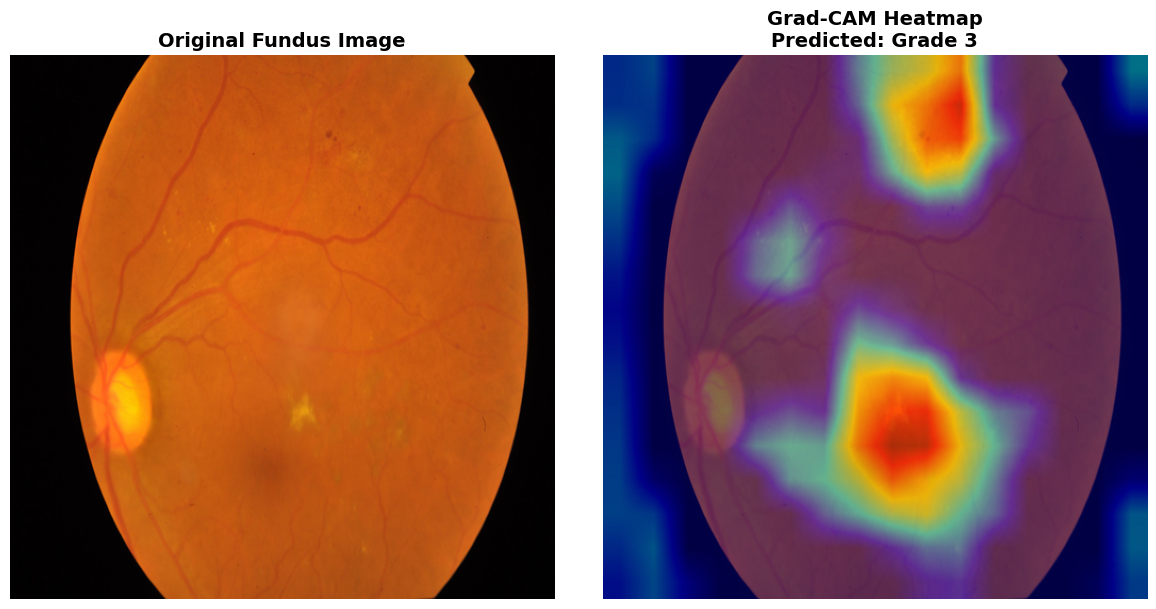

: 

In [ ]:
import json
import random

if __name__ == '__main__':
    # 1. Initialize Configuration
    config = Config()
    
    # 2. Load Tuned Hyperparameters 
    summary_path = config.results_dir / 'tuning_summary.json'
    if summary_path.exists():
        with open(summary_path, 'r') as f:
            summary = json.load(f)
            config.best_head_params = summary['best_cnn_head_params']
        print(f"✅ Successfully loaded tuned parameters from {summary_path}")
    else:
        print("❌ Error: tuning_summary.json not found.")

    # 3. Choose model to visualize
    model_name = 'densenet121' 
    
    # 4. Initialize Manager and Load Weights
    head_params = config.best_head_params[model_name]
    manager = DRModelManager(config, model_name, tuning_params=head_params)
    
    model_path = config.model_dir / f'{model_name}_finetune_best.pth'
    if model_path.exists():
        manager.load_model(model_path)
        
        # 5. Initialize the Visualizer
        xai = XAIVisualizer(config, manager)
        
        # --- NEW: RANDOM IMAGE SELECTION ---
        # Get a list of all image files in the directory
        extensions = {'.png', '.jpg', '.jpeg'}
        all_images = [f for f in config.train_images_dir.iterdir() if f.suffix.lower() in extensions]
        
        if all_images:
            # Pick one random image path
            random_test_image = random.choice(all_images)
            
            # Extract image ID for label lookup if needed
            img_id = random_test_image.stem
            
            # Optional: Lookup true label from your dataframe
            # test_df = pd.read_csv(config.train_csv)
            # true_label = test_df[test_df['id_code'] == img_id]['diagnosis'].values[0]
            
            print(f"🚀 Randomly selected: {random_test_image.name}")
            print(f"Generating Grad-CAM for {model_name}...")
            
            # Run the heatmap generation
            xai.generate_heatmap(random_test_image)
        else:
            print(f"❌ No images found in {config.train_images_dir}")
    else:
        print(f"❌ Trained weights not found at {model_path}")

Successfully saved grid to: results/Classwise_FundusImage.png


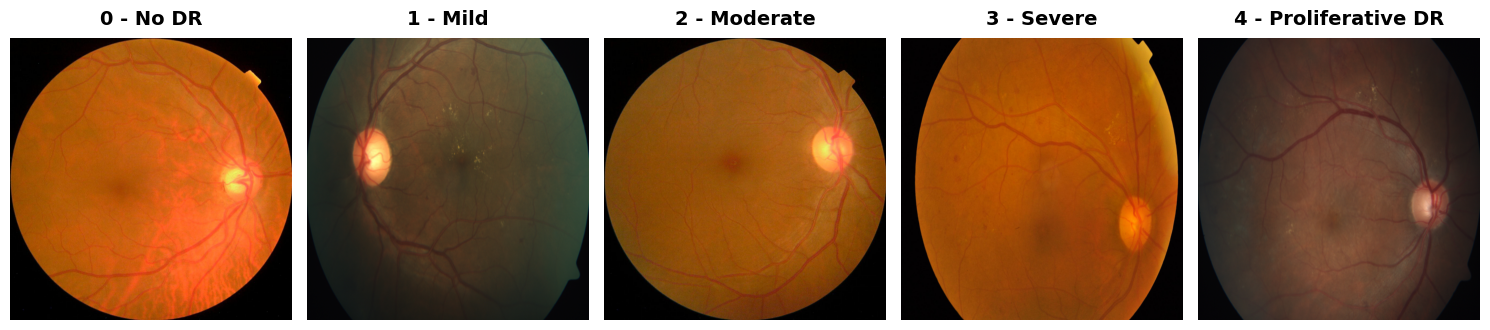

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def create_class_grid(image_dict, output_path="classwise_fundus_grid.png", target_size=(512, 512)):
    """
    Creates a tabular horizontal grid of images with class labels as headers.
    
    Parameters:
    - image_dict: Dictionary mapping column headers (labels) to image file paths.
    - output_path: Where to save the final generated grid.
    - target_size: Tuple of (width, height) to force all images to the exact same size.
    """
    
    num_classes = len(image_dict)
    
    # Create a figure with 1 row and 'num_classes' columns
    # figsize is roughly proportional to the number of columns to keep it wide
    fig, axes = plt.subplots(1, num_classes, figsize=(15, 4))
    
    # If there's only one image, axes won't be an array, so we wrap it
    if num_classes == 1:
        axes = [axes]
        
    for ax, (label, img_path) in zip(axes, image_dict.items()):
        if os.path.exists(img_path):
            # Open the image and force it to the target size
            img = Image.open(img_path)
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
            
            # Display the image
            ax.imshow(img_resized)
        else:
            # Fallback if image path is wrong
            ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center')
            print(f"Warning: Could not find image at {img_path}")
            
        # Set the column header (the class label)
        ax.set_title(label, fontsize=14, fontweight='bold', pad=10)
        
        # Turn off the x and y axis ticks/lines to make it look like a clean table
        ax.axis('off')
        
    # Adjust layout so titles don't overlap and there are no massive white gaps
    plt.tight_layout()
    
    # Save the figure in high resolution (DPI 300 is standard for IEEE papers)
    plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=False)
    print(f"Successfully saved grid to: {output_path}")
    
    # Show it in the notebook
    plt.show()

# --- HOW TO USE IT ---

# 1. Define your labels and the exact paths to the 5 representative images you want to use
class_examples = {
    "0 - No DR": "aptos2019-blindness-detection/train_images/0a38b552372d.png",
    "1 - Mild": "aptos2019-blindness-detection/train_images/0a9ec1e99ce4.png",
    "2 - Moderate": "aptos2019-blindness-detection/train_images/0a4e1a29ffff.png",
    "3 - Severe": "aptos2019-blindness-detection/train_images/0ad7f631dedb.png",
    "4 - Proliferative DR": "aptos2019-blindness-detection/train_images/0a09aa7356c0.png"
}

# 2. Run the function
create_class_grid(
    image_dict=class_examples, 
    output_path="results/Classwise_FundusImage.png", 
    target_size=(512, 512) # This forces them all to be perfect squares
)